
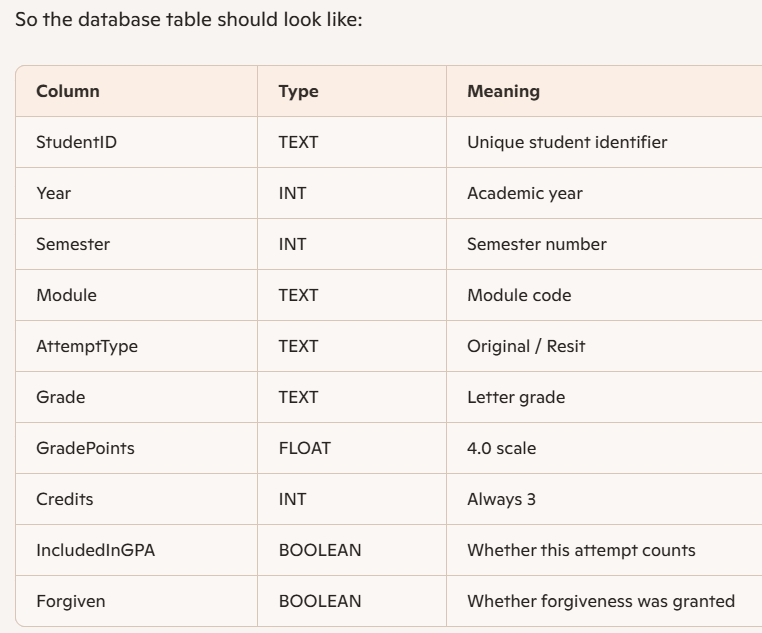
```
# This is formatted as code
```



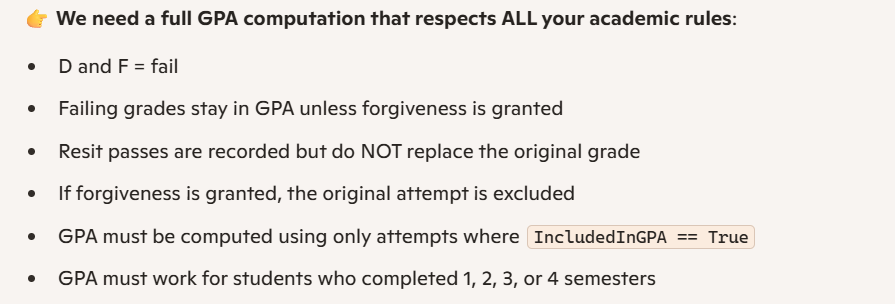

In [4]:
import random
import pandas as pd
import numpy as np

# ---------------------------------------------
# DISPLAY OPTIONS (Compressed DataFrame Output)
# ---------------------------------------------
pd.set_option("display.max_rows", 25)
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 15)
pd.options.display.float_format = "{:.2f}".format

# ---------------------------------------------
# CONFIGURATION
# ---------------------------------------------

ENTRY_YEARS = [2021, 2022, 2023, 2024]

MODULES = {
    "Y1S1": ["Eng1", "Maths1", "IT", "Dbase"],
    "Y1S2": ["Eng2", "Maths2", "SoftEng", "Network"],
    "Y2S1": ["AI1", "Cloud1", "Security1", "Entrep1"],
    "Y2S2": ["AI2", "Cloud2", "Security2", "Entrep2"]
}

GRADE_SCALE = {
    "A": 4.0,
    "B+": 3.5,
    "B": 3.0,
    "C+": 2.5,
    "C": 2.0,
    "D": 1.0,   # Fail
    "F": 0.0    # Fail
}

PASSING_GRADES = ["A", "B+", "B", "C+", "C"]
FAILING_GRADES = ["D", "F"]

GRADE_DISTRIBUTION = {
    "A": 0.15,
    "B+": 0.20,
    "B": 0.25,
    "C+": 0.15,
    "C": 0.10,
    "D": 0.10,
    "F": 0.05
}

# Mixture of students completing different numbers of semesters
COMPLETION_DISTRIBUTION = {
    1: 0.15,   # 1 semester
    2: 0.20,   # 2 semesters
    3: 0.25,   # 3 semesters
    4: 0.40    # 4 semesters
}


In [5]:
# ---------------------------------------------
# HELPER FUNCTIONS
# ---------------------------------------------

def random_grade():
    return random.choices(
        population=list(GRADE_DISTRIBUTION.keys()),
        weights=list(GRADE_DISTRIBUTION.values()),
        k=1
    )[0]

def compute_gpa(df):
    if len(df) == 0:
        return 0
    return (df["GradePoints"] * df["Credits"]).sum() / df["Credits"].sum()

def generate_student_id(entry_year, index):
    """Generate ID like 20230001."""
    return f"{entry_year}{index:04d}"

In [6]:
# ---------------------------------------------
# MAIN SYNTHETIC DATA GENERATOR
# ---------------------------------------------

def generate_student_records(num_students=100):
    records = []

    # Assign each student an entry year
    entry_years = np.random.choice(ENTRY_YEARS, size=num_students)

    for i in range(num_students):
        entry_year = entry_years[i]
        student_id = generate_student_id(entry_year, i + 1)

        # Determine how many semesters this student completed
        completion_depth = random.choices(
            population=[1, 2, 3, 4],
            weights=list(COMPLETION_DISTRIBUTION.values()),
            k=1
        )[0]

        # Loop only through the semesters the student completed
        for year_sem, modules in list(MODULES.items())[:completion_depth]:
            year = int(year_sem[1])
            sem = int(year_sem[3])

            for module in modules:
                grade = random_grade()
                gp = GRADE_SCALE[grade]

                # Original attempt
                records.append({
                    "StudentID": student_id,
                    "EntryYear": entry_year,
                    "Year": year,
                    "Semester": sem,
                    "Module": module,
                    "AttemptType": "Original",
                    "Grade": grade,
                    "GradePoints": gp,
                    "Credits": 3,
                    "IncludedInGPA": True,
                    "Forgiven": False
                })

                # Resit if failed
                if grade in FAILING_GRADES:
                    resit_grade = random.choice(PASSING_GRADES)
                    resit_gp = GRADE_SCALE[resit_grade]

                    included = False
                    forgiven = False

                    # 20% chance of grade forgiveness
                    if random.random() < 0.20:
                        included = True
                        forgiven = True
                        records[-1]["IncludedInGPA"] = False
                        records[-1]["Forgiven"] = True

                    records.append({
                        "StudentID": student_id,
                        "EntryYear": entry_year,
                        "Year": year,
                        "Semester": sem,
                        "Module": module,
                        "AttemptType": "Resit",
                        "Grade": resit_grade,
                        "GradePoints": resit_gp,
                        "Credits": 3,
                        "IncludedInGPA": included,
                        "Forgiven": forgiven
                    })

    return pd.DataFrame(records)

In [7]:
# ---------------------------------------------
# FEATURE ENGINEERING
# ---------------------------------------------

def build_ml_features(df):
    features = []

    for student_id, sdf in df.groupby("StudentID"):
        sdf = sdf.sort_values(["Year", "Semester"])

        for (year, sem), sem_df in sdf.groupby(["Year", "Semester"]):
            gpa_df = sem_df[sem_df["IncludedInGPA"] == True]
            sem_gpa = compute_gpa(gpa_df)

            failed_count = sum(sem_df["Grade"].isin(FAILING_GRADES))
            resits = sum(sem_df["AttemptType"] == "Resit")
            forgiven = sum(sem_df["Forgiven"] == True)

            features.append({
                "StudentID": student_id,
                "EntryYear": sem_df["EntryYear"].iloc[0],
                "Year": year,
                "Semester": sem,
                "SemesterGPA": sem_gpa,
                "FailedModules": failed_count,
                "Resits": resits,
                "ForgivenCount": forgiven
            })

    return pd.DataFrame(features)

In [8]:
# ---------------------------------------------
# RUN
# ---------------------------------------------

if __name__ == "__main__":
    df_records = generate_student_records(num_students=200)
    df_features = build_ml_features(df_records)

    print("Sample Academic Records:")
    print(df_records.head(20))

    # print("\nML Feature Table:")
    # print(df_features.head())

    # Save to CSV
    df_records.to_csv("student_academic_records.csv", index=False)
    # df_features.to_csv("student_ml_features.csv", index=False)

Sample Academic Records:
   StudentID  EntryYear  Year  Semester   Module AttemptType Grade  GradePoints  Credits  IncludedInGPA  Forgiven
0   20210001       2021     1         1     Eng1    Original     B         3.00        3           True     False
1   20210001       2021     1         1   Maths1    Original     B         3.00        3           True     False
2   20210001       2021     1         1       IT    Original     D         1.00        3           True     False
3   20210001       2021     1         1       IT       Resit     B         3.00        3          False     False
4   20210001       2021     1         1    Dbase    Original     D         1.00        3           True     False
5   20210001       2021     1         1    Dbase       Resit    B+         3.50        3          False     False
6   20210001       2021     1         2     Eng2    Original    B+         3.50        3           True     False
7   20210001       2021     1         2   Maths2    Original   

In [ ]:

  print("Sample Academic Records:")
  print(df_records.head(40))


In [10]:
def compute_student_gpa(df_student):
    """
    Computes semester GPA and cumulative GPA for a single student's full record.
    Respects:
      - D/F = fail
      - Resits
      - Grade forgiveness
      - IncludedInGPA flag
    """
    df_student = df_student.sort_values(["Year", "Semester"])

    results = []

    cumulative_points = 0
    cumulative_credits = 0

    for (year, sem), sem_df in df_student.groupby(["Year", "Semester"]):

        # Only include attempts marked as IncludedInGPA
        gpa_df = sem_df[sem_df["IncludedInGPA"] == True]

        # Semester GPA
        if len(gpa_df) > 0:
            sem_points = (gpa_df["GradePoints"] * gpa_df["Credits"]).sum()
            sem_credits = gpa_df["Credits"].sum()
            sem_gpa = sem_points / sem_credits
        else:
            sem_points = 0
            sem_credits = 0
            sem_gpa = 0

        # Update cumulative totals
        cumulative_points += sem_points
        cumulative_credits += sem_credits

        # Cumulative GPA
        if cumulative_credits > 0:
            cumulative_gpa = cumulative_points / cumulative_credits
        else:
            cumulative_gpa = 0

        results.append({
            "Year": year,
            "Semester": sem,
            "SemesterGPA": round(sem_gpa, 3),
            "CumulativeGPA": round(cumulative_gpa, 3),
            "FailedModules": sum(sem_df["Grade"].isin(["D", "F"])),
            "Resits": sum(sem_df["AttemptType"] == "Resit"),
            "Forgiven": sum(sem_df["Forgiven"] == True)
        })

    return pd.DataFrame(results)


In [ ]:

# Compute GPA for one student
student_id = "20230015"
df_student = df_records[df_records["StudentID"] == student_id]

gpa_table = compute_student_gpa(df_student)
print(gpa_table)
